Mean Squared Error: 92035984617.63518


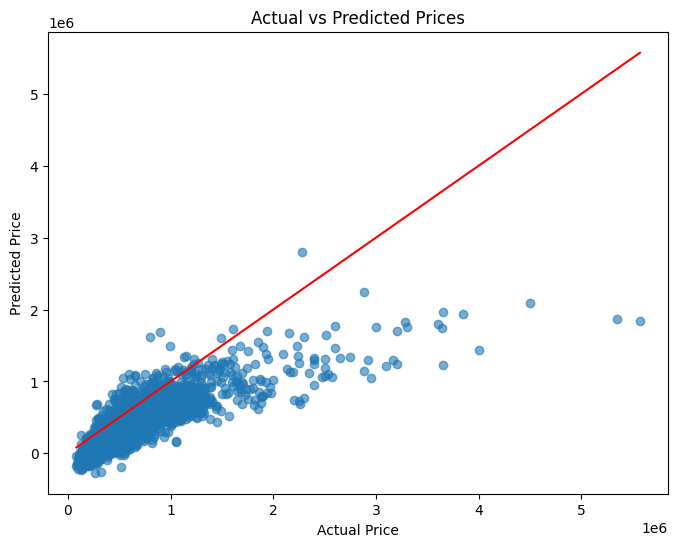

In [90]:
# Linear Regression From Scratch using NumPy

#This notebook implements Linear Regression using gradient descent 
#without using machine learning libraries like scikit-learn.
#The goal is to understand the mathematics and optimization behind
#ML models.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


# -----------------------------
# Data Loading
# -----------------------------

df = pd.read_csv("housing.csv")

# Remove unnecessary columns
df.drop(columns=["date", "id"], inplace=True)

# Features and target
X = df.drop(columns=["price"]).values
y = df["price"].values


# -----------------------------
# Feature Standardization
# -----------------------------

def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std

X = standardize(X)


# -----------------------------
# Train Test Split
# -----------------------------

def train_test_split(X, y, test_size=0.2, random_state=None):

    n_samples = X.shape[0]
    indices = np.arange(n_samples)

    if random_state is not None:
        np.random.seed(random_state)
        np.random.shuffle(indices)

    test_size = int(n_samples * test_size)

    test_idx = indices[:test_size]
    train_idx = indices[test_size:]

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


# -----------------------------
# Linear Regression Model
# -----------------------------

class LinearRegression:

    def __init__(self, lr=0.001, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):

            y_pred = np.dot(X, self.w) + self.b

            error = y_pred - y

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):

        y_pred = np.dot(X, self.w) + self.b
        return y_pred


# -----------------------------
# Model Training
# -----------------------------

model = LinearRegression(lr=0.001, epochs=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# -----------------------------
# Evaluation
# -----------------------------

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)


# -----------------------------
# Visualization
# -----------------------------

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()